In [1]:
import numpy as np
from Solver.AdvReactUni import AdvReactUni1DSolver, AdvReactUni1DEval
from Solver.FVUni2nd import FVUni2nd1D
from Solver.ODE import ESDIRK, DITRExp

Nx = 128 * 1
dt = 1 / Nx / 2 / 1 * 8
tEnd = 0.5

fv = FVUni2nd1D(nx=Nx)
ev = AdvReactUni1DEval(
    fv=fv,
    model="bistable",
    params={"a": 0.5, "k": 100},
)
solver = AdvReactUni1DSolver(eval=ev, ode=ESDIRK("ESDIRK3"))
solverDITR = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

u = np.array([np.sin(fv.xcs * np.pi * 2) * 0.5 + 0.5])

u1_strang = solver.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    mode="strang",
    solve_opts={
        # "max_iter": 50,
        "CFL": 10,
    },
)


iter [2,8], resN [7.3543e-04 / 2.1914e+01]
iter [3,10], resN [1.6399e-03 / 6.8250e+00]
iter [3,14], resN [5.2474e-04 / 6.8250e+00]
iter [4,8], resN [3.3900e-04 / 1.0066e+01]
iter [2,7], resN [5.6126e-04 / 3.0820e+01]
iter [3,7], resN [2.1934e-04 / 9.3694e+00]
iter [4,7], resN [2.7558e-04 / 1.3993e+01]
iter [2,6], resN [2.8438e-03 / 2.8747e+01]
iter [3,7], resN [1.8976e-04 / 8.6405e+00]
iter [4,7], resN [2.3721e-04 / 1.2851e+01]
iter [2,8], resN [9.9531e-04 / 2.9025e+01]
iter [3,8], resN [3.3625e-04 / 9.0182e+00]
iter [4,8], resN [5.2999e-04 / 1.3368e+01]
Step [1], t = [3.1250e-02] uNorm [7.3451194777710365]
iter [2,8], resN [9.9476e-04 / 2.9017e+01]
iter [3,8], resN [3.1688e-04 / 9.0160e+00]
iter [4,8], resN [9.4755e-04 / 1.3364e+01]
iter [2,6], resN [2.4269e-03 / 2.5799e+01]
iter [3,7], resN [1.6081e-04 / 7.6845e+00]
iter [4,7], resN [2.0044e-04 / 1.1382e+01]
iter [2,6], resN [2.0412e-03 / 2.2470e+01]
iter [3,7], resN [1.3454e-04 / 6.6495e+00]
iter [4,7], resN [1.6742e-04 / 9.8145e+00

In [2]:
u1 = solver.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
)


iter [2,10], resN [3.1803e-02 / 3.7817e+01]
iter [2,13], resN [2.1234e-03 / 3.7817e+01]
iter [3,10], resN [1.0408e-02 / 1.1110e+01]
iter [3,13], resN [7.1282e-04 / 1.1110e+01]
iter [4,10], resN [1.4762e-02 / 1.8817e+01]
iter [4,13], resN [7.6840e-04 / 1.8817e+01]
Step [1], t = [3.1250e-02] uNorm [7.346405720042062]
iter [2,10], resN [1.6358e-02 / 3.9024e+01]
iter [2,12], resN [1.8626e-03 / 3.9024e+01]
iter [3,10], resN [3.6650e-03 / 1.1564e+01]
iter [3,12], resN [3.7656e-04 / 1.1564e+01]
iter [4,10], resN [6.4198e-03 / 2.0694e+01]
iter [4,12], resN [7.2301e-04 / 2.0694e+01]
Step [2], t = [6.2500e-02] uNorm [7.639986427878372]
iter [2,10], resN [1.3953e-02 / 4.5092e+01]
iter [2,12], resN [1.7615e-03 / 4.5092e+01]
iter [3,10], resN [1.4313e-03 / 1.3345e+01]
iter [3,11], resN [4.4195e-04 / 1.3345e+01]
iter [4,10], resN [5.8465e-03 / 2.5586e+01]
iter [4,11], resN [2.0466e-03 / 2.5586e+01]
Step [3], t = [9.3750e-02] uNorm [7.795706967602839]
iter [2,10], resN [1.7230e-02 / 5.4287e+01]
iter 

In [3]:
u1Ditr = solverDITR.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
    use_exp=True,
)

iter [[0.5, 1],10], resN [9.4015e+11 / 1.1553e+02]
iter [[0.5, 1],20], resN [nan / 1.1553e+02]
iter [[0.5, 1],30], resN [nan / 1.1553e+02]
iter [[0.5, 1],40], resN [nan / 1.1553e+02]
iter [[0.5, 1],50], resN [nan / 1.1553e+02]
iter [[0.5, 1],60], resN [nan / 1.1553e+02]
iter [[0.5, 1],70], resN [nan / 1.1553e+02]
iter [[0.5, 1],80], resN [nan / 1.1553e+02]
iter [[0.5, 1],90], resN [nan / 1.1553e+02]
iter [[0.5, 1],100], resN [nan / 1.1553e+02]
iter [[0.5, 1],110], resN [nan / 1.1553e+02]
iter [[0.5, 1],120], resN [nan / 1.1553e+02]
iter [[0.5, 1],130], resN [nan / 1.1553e+02]
iter [[0.5, 1],140], resN [nan / 1.1553e+02]
iter [[0.5, 1],150], resN [nan / 1.1553e+02]
iter [[0.5, 1],160], resN [nan / 1.1553e+02]
iter [[0.5, 1],170], resN [nan / 1.1553e+02]
iter [[0.5, 1],180], resN [nan / 1.1553e+02]
iter [[0.5, 1],190], resN [nan / 1.1553e+02]
iter [[0.5, 1],200], resN [nan / 1.1553e+02]
iter [[0.5, 1],210], resN [nan / 1.1553e+02]
iter [[0.5, 1],220], resN [nan / 1.1553e+02]
iter [[0.5, 

/home/harry/projects/reactionTest/reactionTest/Solver/AdvReactUni.py:101: RuntimeWarning: overflow encountered in multiply
  return u * (1 - u) * (u - a) * k
/home/harry/projects/reactionTest/reactionTest/Solver/AdvReactUni.py:276: RuntimeWarning: overflow encountered in multiply
  return JExpo * u
/home/harry/projects/reactionTest/reactionTest/Solver/AdvReactUni.py:90: RuntimeWarning: invalid value encountered in subtract
  df = 0.5 * an * (duRecN) - 0.5 * abs(an) * (duRecN)
/home/harry/projects/reactionTest/reactionTest/Solver/FVUni2nd.py:31: RuntimeWarning: invalid value encountered in subtract
  du = uN - u
/home/harry/projects/reactionTest/reactionTest/Solver/FVUni2nd.py:46: RuntimeWarning: invalid value encountered in subtract
  alphaBJMax = np.minimum(np.abs(uMax - u) / (np.abs(uRecMax) + 1e-300), 1.0)
/home/harry/projects/reactionTest/reactionTest/Solver/FVUni2nd.py:46: RuntimeWarning: invalid value encountered in divide
  alphaBJMax = np.minimum(np.abs(uMax - u) / (np.abs(uRec


iter [[0.5, 1],540], resN [nan / 1.1553e+02]
iter [[0.5, 1],550], resN [nan / 1.1553e+02]
iter [[0.5, 1],560], resN [nan / 1.1553e+02]
iter [[0.5, 1],570], resN [nan / 1.1553e+02]
iter [[0.5, 1],580], resN [nan / 1.1553e+02]
iter [[0.5, 1],590], resN [nan / 1.1553e+02]
iter [[0.5, 1],600], resN [nan / 1.1553e+02]
iter [[0.5, 1],610], resN [nan / 1.1553e+02]
iter [[0.5, 1],620], resN [nan / 1.1553e+02]
iter [[0.5, 1],630], resN [nan / 1.1553e+02]
iter [[0.5, 1],640], resN [nan / 1.1553e+02]
iter [[0.5, 1],650], resN [nan / 1.1553e+02]
iter [[0.5, 1],660], resN [nan / 1.1553e+02]
iter [[0.5, 1],670], resN [nan / 1.1553e+02]
iter [[0.5, 1],680], resN [nan / 1.1553e+02]
iter [[0.5, 1],690], resN [nan / 1.1553e+02]
iter [[0.5, 1],700], resN [nan / 1.1553e+02]
iter [[0.5, 1],710], resN [nan / 1.1553e+02]
iter [[0.5, 1],720], resN [nan / 1.1553e+02]
iter [[0.5, 1],730], resN [nan / 1.1553e+02]
iter [[0.5, 1],740], resN [nan / 1.1553e+02]
iter [[0.5, 1],750], resN [nan / 1.1553e+02]
iter [[0.

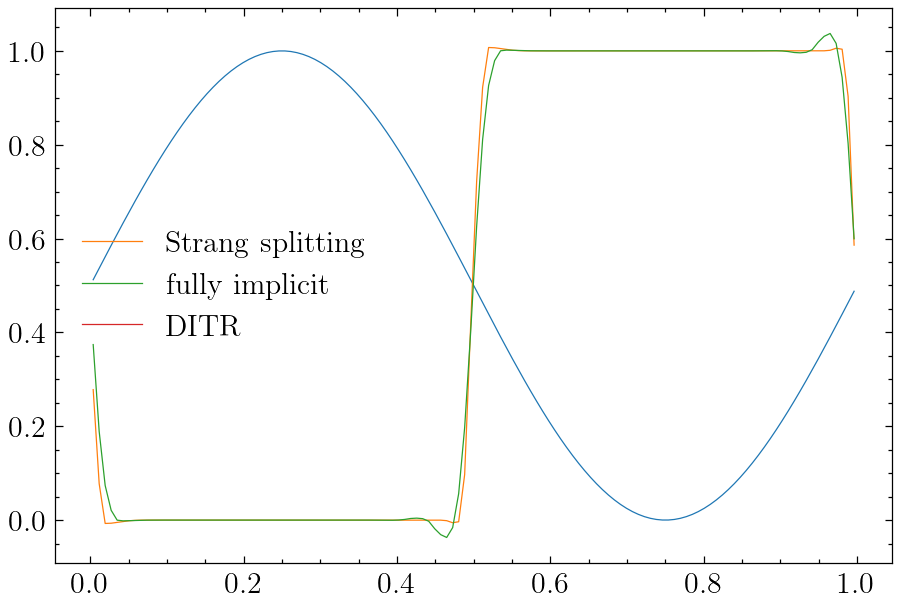

In [4]:
import matplotlib.pyplot as plt
import PlotEnv

plotEnv = PlotEnv.PlotEnv(dpi=180, markEvery=0)

fig = plotEnv.figure(101, figsize=(6, 4))
plotEnv.plot(fv.xcs, u[0], plotIndex=0)
plotEnv.plot(fv.xcs, u1_strang[0], plotIndex=1, label="Strang splitting")
plotEnv.plot(fv.xcs, u1[0], plotIndex=2, label="fully implicit")
plotEnv.plot(fv.xcs, u1Ditr[0], plotIndex=3, label="DITR")
plt.legend()
plt.show()